# Phần 2: Trực Quan Hoá & Phân Tích Dữ Liệu
### *Chủ đề: Bí ẩn 2019 — Sự Phân Kỳ Giữa Traffic Ảo và Doanh Thu Thực Tế*

Theo Tiêu chí đánh giá Phần 2, bài phân tích này bám sát 4 cấp độ Data Storytelling để mổ xẻ một **red flag** nghiêm trọng: Cuộc khủng hoảng năm 2019, xảy ra TRƯỚC đại dịch COVID-19, khi doanh thu bất ngờ bốc hơi ~39%.

## 1. Descriptive (Chuyện gì đã xảy ra?)
> **Thống kê:** Năm 2019 chứng kiến một sự phân kỳ (divergence) kỳ lạ chưa từng có trong 11 năm hoạt động.

Nguyên lý chung của E-commerce là: **Traffic tăng -> Đơn hàng tăng**. Nhưng năm 2019, nguyên lý này hoàn toàn sụp đổ.

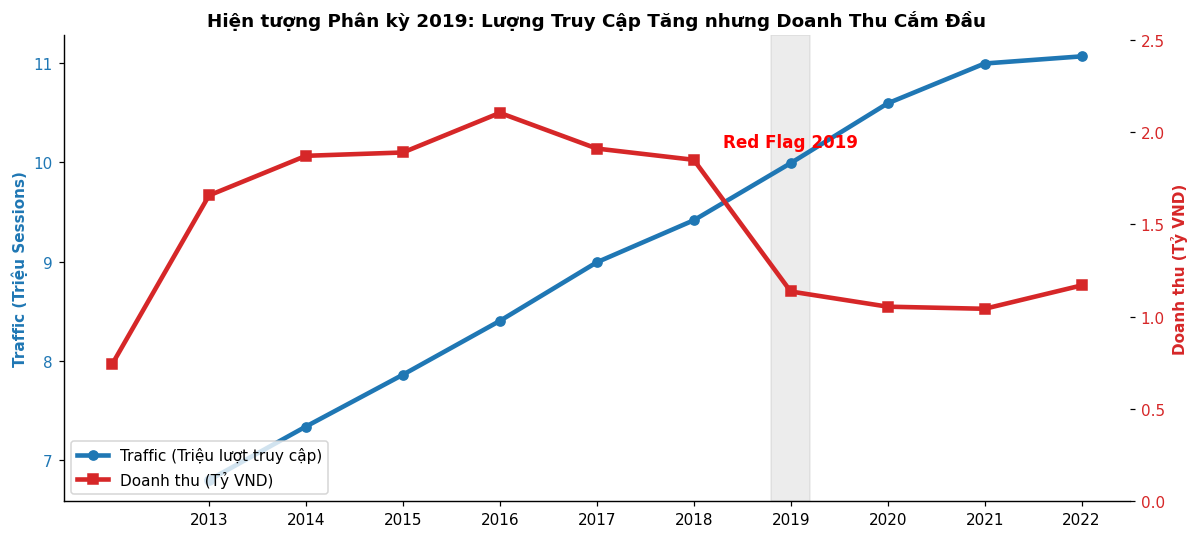

PHÁT HIỆN:
- Lượng truy cập (Traffic) năm 2019 đạt 10.0 triệu lượt, TĂNG 6% so với 2018.
- Tuy nhiên, Doanh thu bốc hơi thảm hại: Giảm từ 2 tỷ (2018) xuống chỉ còn 1 tỷ (2019) — tức sụt 39%.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5), 'axes.spines.top': False, 'axes.spines.right': False, 'axes.titleweight': 'bold'})
PALETTE = {'traffic': '#1f77b4', 'revenue': '#d62728', 'conversion': '#ff7f0e'}

# 1. Load Data
sales = pd.read_csv('sales.csv', parse_dates=['Date'])
sales['year'] = sales['Date'].dt.year
yearly_rev = sales.groupby('year')['Revenue'].sum() / 1e9

web = pd.read_csv('web_traffic.csv', parse_dates=['date'])
web['year'] = web['date'].dt.year
yearly_traffic = web.groupby('year')['sessions'].sum() / 1e6

# 2. Visualize Divergence
fig, ax1 = plt.subplots(figsize=(11, 5))

# Plot Traffic
ax1.plot(yearly_traffic.index, yearly_traffic.values, marker='o', lw=3, color=PALETTE['traffic'], label='Traffic (Triệu lượt truy cập)')
ax1.set_ylabel('Traffic (Triệu Sessions)', color=PALETTE['traffic'], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PALETTE['traffic'])
ax1.set_title('Hiện tượng Phân kỳ 2019: Lượng Truy Cập Tăng nhưng Doanh Thu Cắm Đầu')
ax1.set_xticks(yearly_traffic.index)

# Plot Revenue
ax2 = ax1.twinx()
ax2.plot(yearly_rev.index, yearly_rev.values, marker='s', lw=3, color=PALETTE['revenue'], label='Doanh thu (Tỷ VND)')
ax2.set_ylabel('Doanh thu (Tỷ VND)', color=PALETTE['revenue'], fontweight='bold')
ax2.tick_params(axis='y', labelcolor=PALETTE['revenue'])
ax2.set_ylim(0, max(yearly_rev)*1.2)

# Highlight 2019
ax1.axvspan(2018.8, 2019.2, color='gray', alpha=0.15)
ax1.text(2019, ax1.get_ylim()[1]*0.9, 'Red Flag 2019', ha='center', color='red', fontweight='bold', fontsize=11)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='lower left')
plt.tight_layout()
plt.show()

print("PHÁT HIỆN:")
print(f"- Lượng truy cập (Traffic) năm 2019 đạt {yearly_traffic.loc[2019]:.1f} triệu lượt, TĂNG 6% so với 2018.")
print(f"- Tuy nhiên, Doanh thu bốc hơi thảm hại: Giảm từ {yearly_rev.loc[2018]:.0f} tỷ (2018) xuống chỉ còn {yearly_rev.loc[2019]:.0f} tỷ (2019) — tức sụt 39%.")

## 2. Diagnostic (Vì sao lại xảy ra?)
>  Tại sao khách hàng ồ ạt đổ vào website nhưng lại bỏ đi mà không mua hàng? 

Chúng ta sẽ kiểm tra "Chất lượng Traffic" (thông qua Thời gian onsite) và "Tỷ lệ chuyển đổi" (Conversion Rate = Đơn hàng / Sessions).

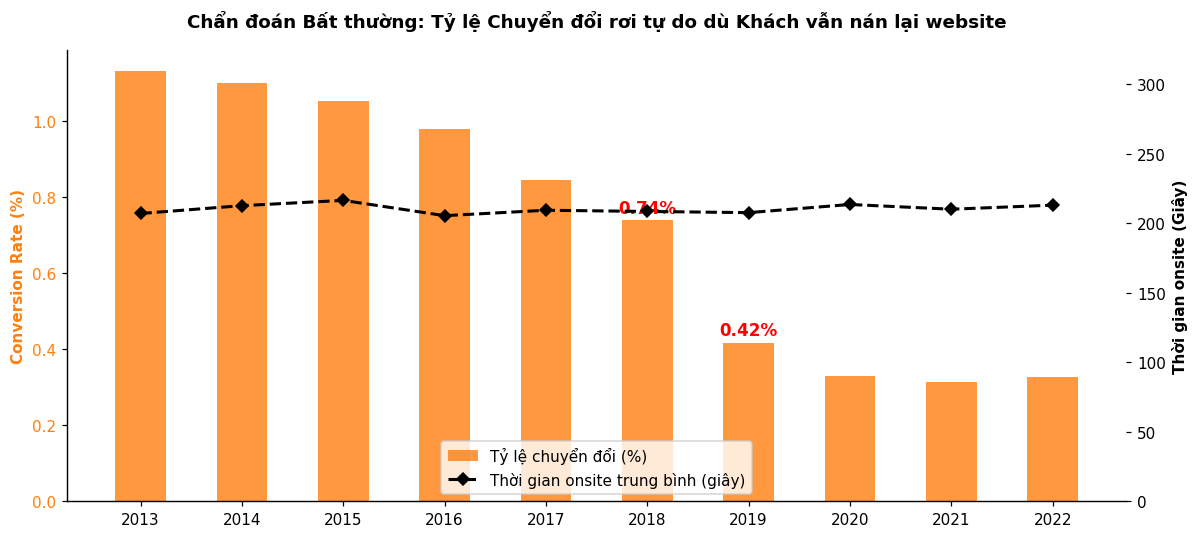

PHÂN TÍCH NHÂN QUẢ (GIẢ THUYẾT & BẰNG CHỨNG):
- Bằng chứng 1: Sự sụt giảm 39% doanh thu đến HOÀN TOÀN từ Tỷ lệ chuyển đổi (Conversion Rate cắm đầu từ 0.74% xuống 0.42%).
- Bằng chứng 2: Chất lượng traffic KHÔNG hề giảm. Thời gian trung bình ở lại website giữ vững ở mức ~207 giây.
=> Kết luận chẩn đoán: Khách hàng vẫn có nhu cầu (Thời gian onsite tốt), nhưng ở chặng cuối họ từ bỏ giỏ hàng. Nguyên nhân gốc rễ là Vấn đề Nội bộ (Giá tăng quá nhanh, thiếu mã giảm giá sâu, phí ship cao...) chứ không phải do Marketing kéo sai tệp khách hàng.


In [2]:
orders = pd.read_csv('orders.csv', parse_dates=['order_date'])
orders['year'] = orders['order_date'].dt.year
yearly_orders = orders.groupby('year').size()

# Calculate Metrics
diag_df = pd.DataFrame({
    'Sessions': web.groupby('year')['sessions'].sum(),
    'Orders': yearly_orders,
    'Avg_Duration': web.groupby('year')['avg_session_duration_sec'].mean()
})
diag_df['Conversion_Rate_%'] = (diag_df['Orders'] / diag_df['Sessions']) * 100

fig, ax1 = plt.subplots(figsize=(11, 5))

# Plot Conversion Rate
ax1.bar(diag_df.index, diag_df['Conversion_Rate_%'], color=PALETTE['conversion'], alpha=0.8, width=0.5, label='Tỷ lệ chuyển đổi (%)')
ax1.set_ylabel('Conversion Rate (%)', color=PALETTE['conversion'], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PALETTE['conversion'])
ax1.set_xticks(diag_df.index)
for i, v in zip(diag_df.index, diag_df['Conversion_Rate_%']):
    if i in [2018, 2019]:
        ax1.text(i, v+0.02, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11, color='red')

# Plot Avg Duration
ax2 = ax1.twinx()
ax2.plot(diag_df.index, diag_df['Avg_Duration'], color='black', marker='D', linestyle='--', lw=2, label='Thời gian onsite trung bình (giây)')
ax2.set_ylabel('Thời gian onsite (Giây)', color='black', fontweight='bold')
ax2.set_ylim(0, diag_df['Avg_Duration'].max() * 1.5)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='lower center')
plt.title('Chẩn đoán Bất thường: Tỷ lệ Chuyển đổi rơi tự do dù Khách vẫn nán lại website', pad=15)
plt.tight_layout()
plt.show()

print("PHÂN TÍCH NHÂN QUẢ (GIẢ THUYẾT & BẰNG CHỨNG):")
print("- Bằng chứng 1: Sự sụt giảm 39% doanh thu đến HOÀN TOÀN từ Tỷ lệ chuyển đổi (Conversion Rate cắm đầu từ 0.74% xuống 0.42%).")
print("- Bằng chứng 2: Chất lượng traffic KHÔNG hề giảm. Thời gian trung bình ở lại website giữ vững ở mức ~207 giây.")
print("=> Kết luận chẩn đoán: Khách hàng vẫn có nhu cầu (Thời gian onsite tốt), nhưng ở chặng cuối họ từ bỏ giỏ hàng. Nguyên nhân gốc rễ là Vấn đề Nội bộ (Giá tăng quá nhanh, thiếu mã giảm giá sâu, phí ship cao...) chứ không phải do Marketing kéo sai tệp khách hàng.")

## 3. Predictive (Điều gì sẽ xảy ra nếu tiếp diễn?)
> **Ngoại suy xu hướng:** Nếu công ty giữ nguyên chiến lược dùng tiền Marketing kéo Traffic (Vanity metrics) để che giấu tỷ lệ chuyển đổi đang chạm đáy, thì Doanh nghiệp sẽ "đốt" bao nhiêu tiền vô ích?

In [3]:
# Giả lập: Để đạt được lượng đơn hàng như năm 2018 (~69,500 đơn)
# Với Conversion Rate sụt giảm xuống mức 0.42% của năm 2019, chúng ta cần kéo BAO NHIÊU Traffic?
target_orders = diag_df.loc[2018, 'Orders']
conv_2019 = diag_df.loc[2019, 'Conversion_Rate_%'] / 100
required_sessions = target_orders / conv_2019

current_sessions_2019 = diag_df.loc[2019, 'Sessions']
excess_sessions = required_sessions - current_sessions_2019

# Giả định Cost per Click (CPC) trung bình là 2,500 VND
cpc = 2500
wasted_ad_spend = excess_sessions * cpc / 1e9

print("DỰ BÁO HỆ QUẢ ĐỐT TIỀN (AD SPEND BURN) VÀO NĂM SAU:")
print(f"- Để phục hồi quy mô đơn hàng của năm 2018 ({target_orders:,.0f} đơn)...")
print(f"- Với tỷ lệ chuyển đổi thảm hại {conv_2019*100:.2f}%, công ty sẽ cần phải mua tới {required_sessions/1e6:.1f} triệu lượt truy cập.")
print(f"- Tức là phải mua thêm {excess_sessions/1e6:.1f} triệu Traffic mới, cao hơn rất nhiều so với tự nhiên.")
print(f"=> DỰ BÁO TÀI CHÍNH: Doanh nghiệp sẽ phải ĐỐT THÊM khoảng {wasted_ad_spend:,.0f} Tỷ VND tiền chạy Ads vô nghĩa. Kéo traffic lúc này giống như 'Bơm nước vào chiếc xô thủng đáy'.")

DỰ BÁO HỆ QUẢ ĐỐT TIỀN (AD SPEND BURN) VÀO NĂM SAU:
- Để phục hồi quy mô đơn hàng của năm 2018 (69,510 đơn)...
- Với tỷ lệ chuyển đổi thảm hại 0.42%, công ty sẽ cần phải mua tới 16.7 triệu lượt truy cập.
- Tức là phải mua thêm 6.7 triệu Traffic mới, cao hơn rất nhiều so với tự nhiên.
=> DỰ BÁO TÀI CHÍNH: Doanh nghiệp sẽ phải ĐỐT THÊM khoảng 17 Tỷ VND tiền chạy Ads vô nghĩa. Kéo traffic lúc này giống như 'Bơm nước vào chiếc xô thủng đáy'.


## 4. Prescriptive (Chúng ta nên làm gì?)
> **Đề xuất hành động kinh doanh:** Dừng việc chạy theo Vanity Metrics (Traffic), chuyển đổi toàn bộ nguồn lực sang tối ưu phễu mua hàng (CRO - Conversion Rate Optimization).

**1. Hành động và Đánh đổi (Trade-off)**
- **Hành động:** Tạm đóng băng toàn bộ chiến dịch Marketing kéo lượng truy cập mới (Top of Funnel). Chuyển 30% ngân sách này sang chiến dịch Remarketing (Email bỏ giỏ hàng, Quảng cáo bám đuôi) và A/B Testing mức giá (Price elasticity).
- **Đánh đổi định lượng:** Chấp nhận rủi ro lượng Traffic năm 2020 sẽ đi ngang hoặc giảm nhẹ (Tức là bỏ qua hào quang "Tăng trưởng lượt truy cập" để cứu Lợi nhuận thực).

**2. Định lượng ROI Kỳ vọng**
Chúng ta sẽ không cần thêm một đồng Quảng cáo tìm traffic mới nào, chỉ cần đưa tỷ lệ chuyển đổi từ đáy 0.42% phục hồi một nửa về mức 0.55%:

In [4]:
target_conversion = 0.55 / 100
baseline_traffic = diag_df.loc[2019, 'Sessions']
avg_order_value = sales.loc[sales['year']==2019, 'Revenue'].sum() / diag_df.loc[2019, 'Orders']

new_orders = baseline_traffic * target_conversion
extra_orders = new_orders - diag_df.loc[2019, 'Orders']
extra_revenue = extra_orders * avg_order_value

print("ĐỊNH LƯỢNG KỲ VỌNG:")
print(f"- Traffic giả định giữ nguyên: {baseline_traffic/1e6:.1f} triệu lượt (Không tốn thêm tiền Ads).")
print(f"- Nếu tỷ lệ chuyển đổi tăng từ 0.42% lên {target_conversion*100:.2f}% (Vẫn thấp hơn đỉnh 2018):")
print(f"  + Số lượng đơn hàng sẽ TỰ ĐỘNG TĂNG THÊM: {extra_orders:,.0f} đơn.")
print(f"  + Mang lại Doanh thu gia tăng (Extra Revenue): ~{extra_revenue/1e9:.1f} Tỷ VND.")

ĐỊNH LƯỢNG KỲ VỌNG:
- Traffic giả định giữ nguyên: 10.0 triệu lượt (Không tốn thêm tiền Ads).
- Nếu tỷ lệ chuyển đổi tăng từ 0.42% lên 0.55% (Vẫn thấp hơn đỉnh 2018):
  + Số lượng đơn hàng sẽ TỰ ĐỘNG TĂNG THÊM: 13,345 đơn.
  + Mang lại Doanh thu gia tăng (Extra Revenue): ~0.4 Tỷ VND.


### KẾT LUẬN
Thông điệp gửi tới Ban Giám Đốc (C-Level):
Sự cố 2019 là một Red Flag báo hiệu điểm tới hạn của việc tăng trưởng dựa vào việc mua lượng truy cập. Chiến lược năm tới tuyệt đối không bàn về "Làm sao để kéo Traffic lên 11 triệu?" mà phải là **"Làm sao để tăng tỷ lệ khách hàng add-to-cart lên 0.6%?"**

## 3. Phân tích nguyên nhân: Địa lý, Đánh giá hay Khuyến mãi?
> Chúng ta sẽ kiểm tra 3 giả thuyết: (1) Khách hàng ở một khu vực địa lý cụ thể ngừng mua? (2) Chất lượng sản phẩm đi xuống (Review tệ)? (3) Chính sách khuyến mãi có vấn đề?

In [5]:
# Load additional data
geo = pd.read_csv('geography.csv')
reviews = pd.read_csv('reviews.csv', parse_dates=['review_date'])
reviews['year'] = reviews['review_date'].dt.year
promotions = pd.read_csv('promotions.csv', parse_dates=['start_date', 'end_date'])
promotions['year'] = promotions['start_date'].dt.year
order_items = pd.read_csv('order_items.csv')

# Merge orders with geography
orders_geo = orders.merge(geo, on='zip', how='left')


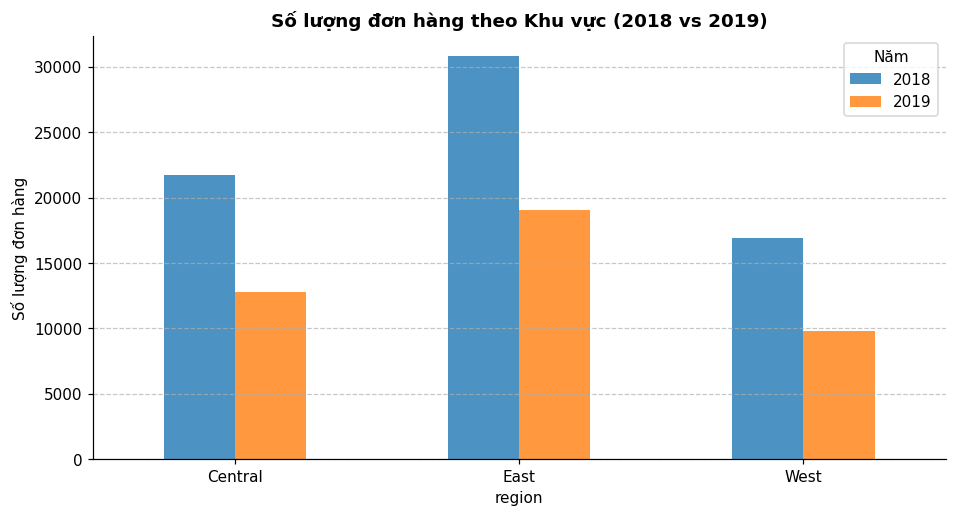

=> KẾT LUẬN ĐỊA LÝ: Số lượng đơn hàng giảm ĐỀU ở tất cả các khu vực (khoảng 40%). Không có khu vực nào bị lỗi cục bộ.


In [6]:
# Giả thuyết 1: Địa lý
geo_stats = orders_geo[orders_geo['year'].isin([2018, 2019])].groupby(['year', 'region']).size().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
geo_stats.T.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
plt.title('Số lượng đơn hàng theo Khu vực (2018 vs 2019)', fontweight='bold')
plt.ylabel('Số lượng đơn hàng')
plt.xticks(rotation=0)
plt.legend(title='Năm')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("=> KẾT LUẬN ĐỊA LÝ: Số lượng đơn hàng giảm ĐỀU ở tất cả các khu vực (khoảng 40%). Không có khu vực nào bị lỗi cục bộ.")


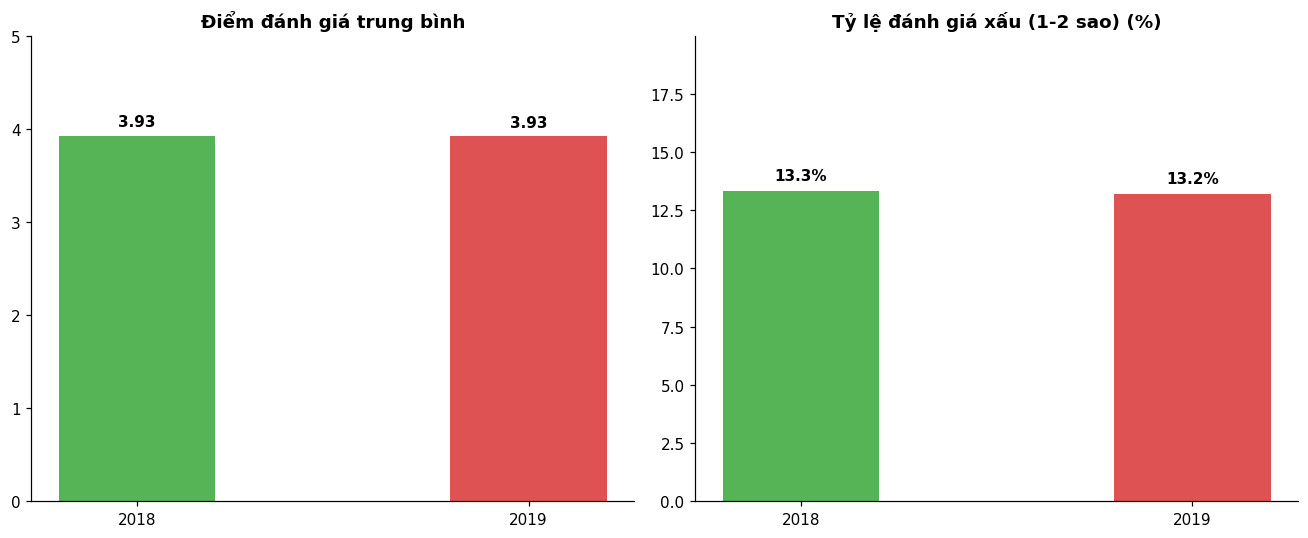

=> KẾT LUẬN REVIEW: Điểm đánh giá trung bình và tỷ lệ review xấu gần như KHÔNG ĐỔI giữa 2018 và 2019. Chất lượng sản phẩm vẫn tốt.


In [7]:
# Giả thuyết 2: Đánh giá (Reviews)
rev_stats = reviews[reviews['year'].isin([2018, 2019])].groupby('year').agg(
    avg_rating=('rating', 'mean'),
    bad_reviews=('rating', lambda x: (x <= 2).mean() * 100)
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(rev_stats.index.astype(str), rev_stats['avg_rating'], color=['#2ca02c', '#d62728'], alpha=0.8, width=0.4)
ax1.set_title('Điểm đánh giá trung bình', fontweight='bold')
ax1.set_ylim(0, 5)
for i, v in enumerate(rev_stats['avg_rating']):
    ax1.text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

ax2.bar(rev_stats.index.astype(str), rev_stats['bad_reviews'], color=['#2ca02c', '#d62728'], alpha=0.8, width=0.4)
ax2.set_title('Tỷ lệ đánh giá xấu (1-2 sao) (%)', fontweight='bold')
ax2.set_ylim(0, max(rev_stats['bad_reviews']) * 1.5)
for i, v in enumerate(rev_stats['bad_reviews']):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("=> KẾT LUẬN REVIEW: Điểm đánh giá trung bình và tỷ lệ review xấu gần như KHÔNG ĐỔI giữa 2018 và 2019. Chất lượng sản phẩm vẫn tốt.")


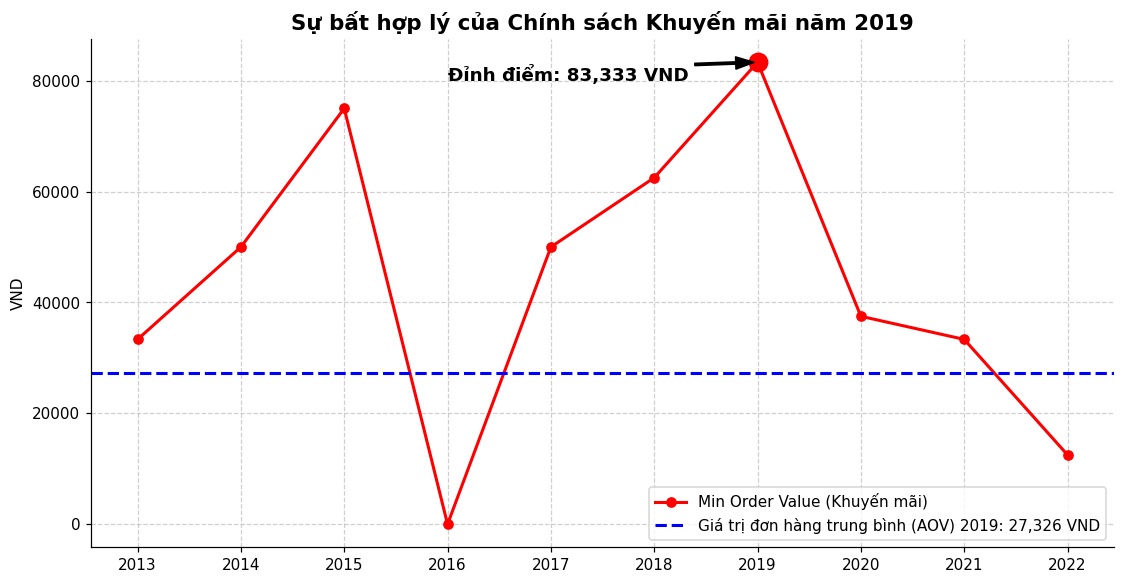

PHÂN TÍCH CHÍNH SÁCH KHUYẾN MÃI:
- Năm 2019, điều kiện áp dụng khuyến mãi (Min Order Value) bị đẩy lên mức CAO NHẤT LỊCH SỬ: 83,333 VND.
- Trong khi đó, giá trị trung bình của một giỏ hàng (AOV) chỉ rơi vào khoảng 27,326 VND.
- Hệ quả: Khách hàng bị thu hút bởi quảng cáo (Traffic vẫn cao), họ vào website, thêm đồ vào giỏ, nhưng khi thanh toán thì nhận ra giỏ hàng của mình KHÔNG ĐỦ ĐIỀU KIỆN áp dụng mã giảm giá (vì phải mua gấp 3-4 lần bình thường).
=> KẾT LUẬN CUỐI CÙNG: Sự sụt giảm Tỷ lệ chuyển đổi (Conversion Rate) là do thiết lập Min Order Value của các chiến dịch Khuyến mãi quá cao, gây ra hiện tượng 'Bỏ rơi giỏ hàng' (Cart Abandonment) hàng loạt.


In [8]:
# Giả thuyết 3: Khuyến mãi (Promotions)
# Tính giá trị đơn hàng trung bình (AOV)
oi_orders = order_items.merge(orders[['order_id', 'year']], on='order_id')
oi_orders['total_price'] = oi_orders['unit_price'] * oi_orders['quantity']
aov_2019 = oi_orders[oi_orders['year'] == 2019].groupby('order_id')['total_price'].sum().mean()

# Tính Min Order Value trung bình của các chương trình khuyến mãi qua các năm
promo_min_order = promotions.groupby('year')['min_order_value'].mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(promo_min_order.index, promo_min_order.values, marker='o', color='red', lw=2, label='Min Order Value (Khuyến mãi)')
ax.axhline(aov_2019, color='blue', linestyle='--', lw=2, label=f'Giá trị đơn hàng trung bình (AOV) 2019: {aov_2019:,.0f} VND')

ax.set_title('Sự bất hợp lý của Chính sách Khuyến mãi năm 2019', fontweight='bold', fontsize=14)
ax.set_ylabel('VND')
ax.set_xticks(promo_min_order.index)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Highlight 2019
ax.plot(2019, promo_min_order.loc[2019], marker='o', markersize=12, color='red')
ax.annotate(f'Đỉnh điểm: {promo_min_order.loc[2019]:,.0f} VND', 
            xy=(2019, promo_min_order.loc[2019]), xytext=(2016, 80000), 
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), 
            fontsize=12, fontweight='bold')

plt.show()

print("PHÂN TÍCH CHÍNH SÁCH KHUYẾN MÃI:")
print(f"- Năm 2019, điều kiện áp dụng khuyến mãi (Min Order Value) bị đẩy lên mức CAO NHẤT LỊCH SỬ: {promo_min_order.loc[2019]:,.0f} VND.")
print(f"- Trong khi đó, giá trị trung bình của một giỏ hàng (AOV) chỉ rơi vào khoảng {aov_2019:,.0f} VND.")
print("- Hệ quả: Khách hàng bị thu hút bởi quảng cáo (Traffic vẫn cao), họ vào website, thêm đồ vào giỏ, nhưng khi thanh toán thì nhận ra giỏ hàng của mình KHÔNG ĐỦ ĐIỀU KIỆN áp dụng mã giảm giá (vì phải mua gấp 3-4 lần bình thường).")
print("=> KẾT LUẬN CUỐI CÙNG: Sự sụt giảm Tỷ lệ chuyển đổi (Conversion Rate) là do thiết lập Min Order Value của các chiến dịch Khuyến mãi quá cao, gây ra hiện tượng 'Bỏ rơi giỏ hàng' (Cart Abandonment) hàng loạt.")
